In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [89]:
house_price=pd.read_csv(r"C:\Users\jyoti singh\Data Science\machine_learning\regression\Housing.csv")

In [90]:
house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [91]:
house_price.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [92]:
house_price.shape

(545, 13)

In [93]:
house_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [94]:
house_price.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [95]:
house_price.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [96]:
house_price.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [97]:
house_price.duplicated().sum()

np.int64(0)

In [98]:
correlation=house_price

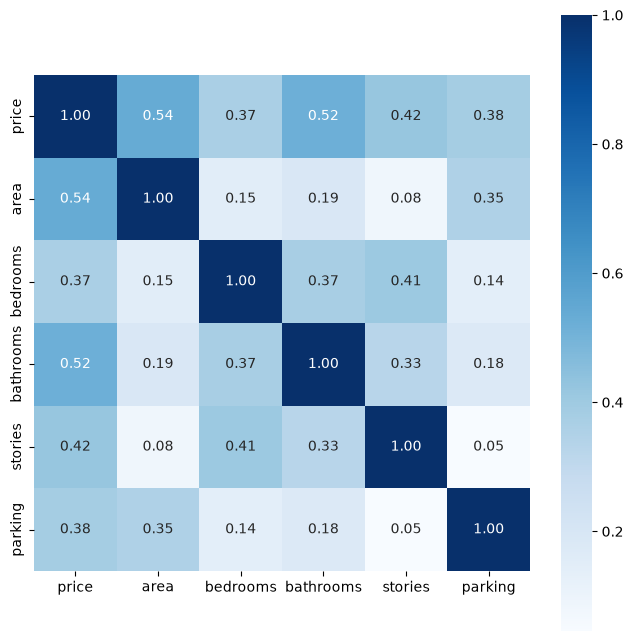

In [99]:
correlation = house_price.corr(numeric_only=True)

plt.figure(figsize=(8,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    square=True
)

plt.show()

In [100]:
#convert categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

house_price["mainroad"] = le.fit_transform(house_price["mainroad"])
house_price["guestroom"] = le.fit_transform(house_price["guestroom"])
house_price["basement"] = le.fit_transform(house_price["basement"])
house_price["hotwaterheating"] = le.fit_transform(house_price["hotwaterheating"])
house_price["airconditioning"] = le.fit_transform(house_price["airconditioning"])
house_price["prefarea"] = le.fit_transform(house_price["prefarea"])
house_price["furnishingstatus"] = le.fit_transform(house_price["furnishingstatus"])

In [101]:
#splitting the data and target
X=house_price.drop(['price'],axis=1)
Y=house_price['price']


In [102]:
print(X)

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                  0              

In [103]:
print(Y)

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64


In [104]:
# Train-Test Split (80% Train, 20% Test)

X_train, X_test, Y_train, Y_test = train_test_split( X,Y,test_size=0.2,random_state=42)


In [105]:
print(X.shape, X_train.shape, X_test.shape)

(545, 12) (436, 12) (109, 12)


In [115]:
#FEATURE SCALING (Standardization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [116]:
#Model training
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 519288.13, 58690.92, 523153.38,..., 192786.99, 266661.05,-158183.27]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.707e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[33.02,26.4 ,23.34,...,16.22,15.65,13.04]"


In [134]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

In [135]:
comparison = pd.DataFrame({
    "Actual Price": Y_test.values,
    "Predicted Price": Y_pred
})

print(comparison.head(20))

    Actual Price  Predicted Price
0        4060000     5.203692e+06
1        6650000     7.257004e+06
2        3710000     3.062829e+06
3        6440000     4.559592e+06
4        2800000     3.332932e+06
5        4900000     3.563081e+06
6        5250000     5.645466e+06
7        4543000     6.413980e+06
8        2450000     2.755832e+06
9        3353000     2.668939e+06
10      10150000     9.570600e+06
11       2660000     2.827432e+06
12       3360000     3.195686e+06
13       3360000     3.352264e+06
14       2275000     3.713879e+06
15       2660000     5.301088e+06
16       2660000     2.987920e+06
17       7350000     4.810800e+06
18       2940000     4.383032e+06
19       2870000     3.525092e+06


In [136]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [137]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for name, model in models.items():

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    mae = mean_absolute_error(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, Y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [139]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.796797e+05  1.331071e+06  0.649475
2      Random Forest  1.026700e+06  1.400766e+06  0.611808
3                KNN  1.037650e+06  1.452136e+06  0.582813
1      Decision Tree  1.222399e+06  1.639566e+06  0.468169
4                SVR  1.763889e+06  2.359648e+06 -0.101565


In [118]:
for name, model in models.items():
    # Fit the model on training data
    model.fit(X_train_scaled, Y_train)
    
    # Predict on test data
    Y_pred = model.predict(X_test_scaled)

In [109]:
Y_pred = model.predict(X_test)

In [126]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("r² Score:", r2)

MAE : 964058.8730464155
MSE : 1694870370248.4102
RMSE: 1301871.871671099
r² Score: 0.6646855642239725
